# 🧬 Augmentation de dataset — Générateur de Contenu IA Cosmétique
## 220 photos produits → 600 images, dans `data/raw/dataset_augmented`

**Objectif de ce notebook, et seulement celui-ci :** partir de tes 220 photos dans
`Stage_1_ouvrier/data/raw/product_photos` et produire un dossier `Stage_1_ouvrier/data/raw/dataset_augmented`
contenant 600 images au total (les 220 originales + 380 variantes augmentées), pour donner plus tard assez de
matière à un modèle qui doit s'adapter à n'importe quel produit cosmétique (packaging, angle, éclairage).

**Tout est open source :**
- **albumentations** (MIT) — bibliothèque d'augmentation d'images, standard en vision par ordinateur.
- **OpenCV** (Apache 2.0) — lecture/écriture d'images.

**GPU :** cette étape est purement CPU (pas de réseau de neurones), un runtime standard suffit. Le GPU sera
nécessaire pour l'étape suivante (détourage + génération de décor), pas ici.


In [4]:
# ## Cellule 1 - Installation

# %%
!pip uninstall -y albumentations albucore
!pip install -q --no-cache-dir --upgrade albumentations opencv-python-headless tqdm

print("Installation terminee.")


Found existing installation: albumentations 1.4.15
Uninstalling albumentations-1.4.15:
  Successfully uninstalled albumentations-1.4.15
Found existing installation: albucore 0.0.24
Uninstalling albucore-0.0.24:
  Successfully uninstalled albucore-0.0.24
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 98.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 189.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.7/676.7 kB 128.2 MB/s eta 0:00:00
Installation terminee.


In [1]:
# ## Cellule 2 - Connexion Google Drive et chemins

# %%
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Stage_1_ouvrier/data')
RAW_DIR = DRIVE_ROOT / 'raw' / 'product_photos'
AUG_DIR = DRIVE_ROOT / 'raw' / 'dataset_augmented'
AUG_DIR.mkdir(parents=True, exist_ok=True)

image_paths = (
    sorted(RAW_DIR.glob("*.jpg"))
    + sorted(RAW_DIR.glob("*.jpeg"))
    + sorted(RAW_DIR.glob("*.png"))
)
n_originals = len(image_paths)
print(f"{n_originals} photos originales trouvees dans {RAW_DIR}")
print(f"Dossier de sortie: {AUG_DIR}")


Mounted at /content/drive
213 photos originales trouvees dans /content/drive/MyDrive/Stage_1_ouvrier/data/raw/product_photos
Dossier de sortie: /content/drive/MyDrive/Stage_1_ouvrier/data/raw/dataset_augmented


## Cellule 3 - Pipeline d'augmentation

Deux familles de transformations, appliquees ensemble mais avec des roles differents :

- **Augmentations geometriques** (le cœur de la demande) : miroir horizontal, rotation legere, mise a l'echelle,
  perspective, cisaillement (shear) et translation. Elles simulent des angles de prise de vue et des cadrages
  differents — utile pour qu'un futur modele de detection/detourage generalise a n'importe quelle photo produit,
  quel que soit l'angle sous lequel elle a ete prise.
- **Augmentations photometriques** (complementaires, probabilite plus faible) : luminosite/contraste, teinte/
  saturation, bruit gaussien leger, flou de mouvement leger. Elles simulent des conditions d'eclairage et de
  qualite de camera differentes.

Les bords generes par la rotation/perspective sont remplis par reflet (`BORDER_REFLECT_101`) plutot que par du
noir, pour rester coherent visuellement (l'etape de detourage plus tard retirera de toute facon l'arriere-plan).


In [2]:
# %%
import cv2
import albumentations as A

MAX_SIDE = 1600  # limite la taille avant augmentation, pour un stockage Drive raisonnable


def resize_if_needed(image, max_side: int = MAX_SIDE):
    h, w = image.shape[:2]
    if max(h, w) <= max_side:
        return image
    ratio = max_side / max(h, w)
    return cv2.resize(image, (round(w * ratio), round(h * ratio)), interpolation=cv2.INTER_AREA)


geometric_augmentations = [
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.Affine(
        scale=(0.9, 1.15),
        translate_percent=(0.0, 0.05),
        shear=(-8, 8),
        mode=cv2.BORDER_REFLECT_101,
        p=0.6,
    ),
    A.Perspective(scale=(0.02, 0.06), pad_mode=cv2.BORDER_REFLECT_101, p=0.4),
]

photometric_augmentations = [
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.4),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2),
]

augmentation_pipeline = A.Compose(geometric_augmentations + photometric_augmentations)

print("Pipeline d'augmentation prete.")


Pipeline d'augmentation prete.


/tmp/ipykernel_721/3687181658.py:19: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(
/tmp/ipykernel_721/3687181658.py:26: UserWarning: Argument(s) 'pad_mode' are not valid for transform Perspective
  A.Perspective(scale=(0.02, 0.06), pad_mode=cv2.BORDER_REFLECT_101, p=0.4),
/tmp/ipykernel_721/3687181658.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),


In [6]:
# ## Cellule 4 - Generation du dataset augmente (220 -> 600 images)

# %%
import json
import shutil
from tqdm import tqdm

TARGET_TOTAL = 600
n_augmented_needed = max(0, TARGET_TOTAL - n_originals)

print(f"Originales: {n_originals} | Augmentees a generer: {n_augmented_needed} | Total vise: {n_originals + n_augmented_needed}")

manifest = {"originales": [], "augmentees": []}

# 1) Copier les originales (redimensionnees si besoin) dans le dossier augmente
for path in tqdm(image_paths, desc="Copie des originales"):
    image = cv2.imread(str(path))
    if image is None:
        print(f"Lecture impossible, ignoree: {path.name}")
        continue
    image = resize_if_needed(image)
    out_path = AUG_DIR / path.name
    cv2.imwrite(str(out_path), image)
    manifest["originales"].append(path.name)

# 2) Generer les variantes augmentees, en repartissant equitablement sur toutes les images (round-robin)
for i in tqdm(range(n_augmented_needed), desc="Generation des augmentations"):
    src_path = image_paths[i % n_originals]
    image = cv2.imread(str(src_path))
    if image is None:
        continue
    image = resize_if_needed(image)
    augmented = augmentation_pipeline(image=image)["image"]

    variant_index = i // n_originals + 1
    out_name = f"{src_path.stem}_aug{variant_index}{src_path.suffix}"
    out_path = AUG_DIR / out_name
    cv2.imwrite(str(out_path), augmented)
    manifest["augmentees"].append({"source": src_path.name, "fichier": out_name})

manifest_path = AUG_DIR / "augmentation_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

total_final = len(manifest["originales"]) + len(manifest["augmentees"])
print(f"\nTermine : {total_final} images dans {AUG_DIR}")
print(f"Manifest detaille: {manifest_path}")


Originales: 213 | Augmentees a generer: 387 | Total vise: 600


Generation des augmentations: 100%|██████████| 387/387 [00:40<00:00,  9.62it/s]


Termine : 600 images dans /content/drive/MyDrive/Stage_1_ouvrier/data/raw/dataset_augmented
Manifest detaille: /content/drive/MyDrive/Stage_1_ouvrier/data/raw/dataset_augmented/augmentation_manifest.json


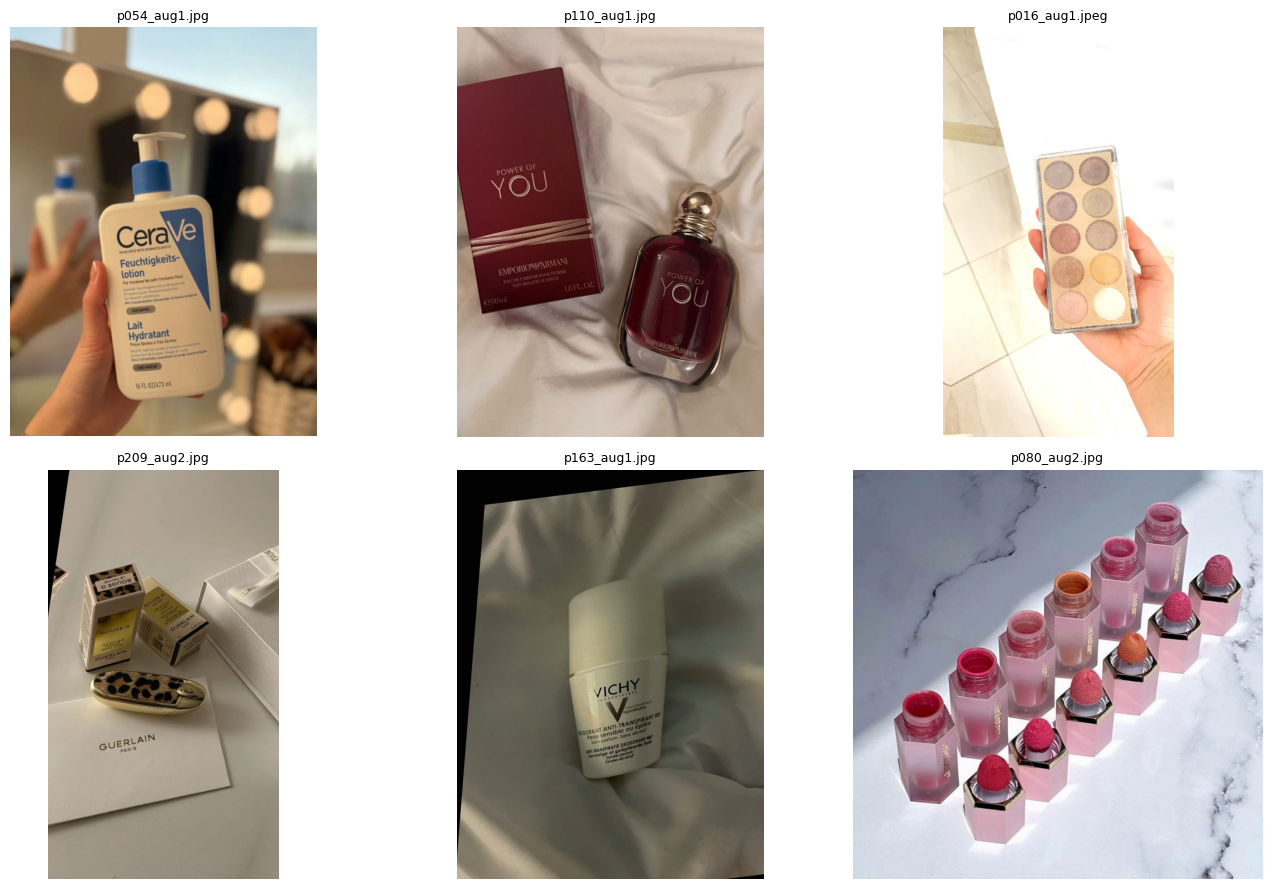

Nombre total de fichiers dans dataset_augmented: 601 (inclut le manifest JSON)


In [3]:
# ## Cellule 5 - Verification visuelle rapide (echantillon)

# %%
import random
import matplotlib.pyplot as plt
from PIL import Image

all_aug_files = sorted(AUG_DIR.glob("*_aug*"))
sample = random.sample(all_aug_files, min(6, len(all_aug_files)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, file_path in zip(axes.ravel(), sample):
    img = Image.open(file_path)
    ax.imshow(img)
    ax.set_title(file_path.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Nombre total de fichiers dans {AUG_DIR.name}: {len(list(AUG_DIR.glob('*.*')))} (inclut le manifest JSON)")
